# Cycle 2 — Data Exploration Wyscout Shot Events (xG)

**Dataset:** `data/raw/events_England.json` 

A complete (EDA) Exploratory data analysis on the shot-event data before building the xG model. Covers schema, target imbalance, spatial distribution, leakage candidate review, feature distributions, correlation, and target-vs-feature plots.

In [5]:
import sys, os  


_here = os.getcwd()                                      
while not os.path.isdir(os.path.join(_here, 'data')):    
    _p = os.path.dirname(_here)                          
    if _p == _here: raise RuntimeError('project root not found')  
    _here = _p
if _here not in sys.path:
    sys.path.insert(0, _here)                        

from config import Paths, ensure_dirs  
ensure_dirs() 


### Setup 

Loading the raw Wysouct England Events JSON file - understanding the full dataset structure what event type exists, how many shots vs passes vs duels, and what fields each event has.

In [6]:
import json                           # parse Wyscout JSON event file
import pandas as pd                 
import numpy as np                  
import matplotlib.pyplot as plt     
import seaborn as sns               
import warnings
warnings.filterwarnings('ignore')   
sns.set_style('whitegrid')          

with open(str(Paths.EVENTS_ENGLAND)) as f:
    raw = json.load(f)                 # load Wyscout England events as a list of dicts
df = pd.DataFrame(raw)                 # convert to DataFrame (643,150 rows × event fields)
print(f'Total events: {len(df):,}')
print(f'Event types: {df["eventName"].nunique()}')  # number of distinct event categories
print()
print('Top event types:')
print(df['eventName'].value_counts().head(10))  # most common event types


Total events: 643,150
Event types: 10

Top event types:
eventName
Pass                       328657
Duel                       176688
Others on the ball          51085
Free Kick                   36423
Interruption                27535
Shot                         8451
Foul                         8138
Save attempt                 3349
Offside                      1558
Goalkeeper leaving line      1266
Name: count, dtype: int64


- There are 643,150 events across all event types in the 2017-18 PL season. With passes dominating (51.1%) of all events and duels making up (27.5%), then a long tail of freekicks, interruptions etc. 
- Shots are only (1.3%) of total events with a totla of 8,451. 

### Filtering - Shots Only

Filterling events down to target just shot events, as shots only are relevant for expected goals (xG) prediciton. Every other event type (pass,duel,tackle etc.) will all be discarded. I should expect a total of 8,451 shots which average 22 shots per match across 380 matches. 

In [7]:
shots = df[df['eventName'] == 'Shot'].copy().reset_index(drop=True)  # keep only Shot events
print(f'Total shots: {len(shots):,}')                                  # ~8,451
print(f'Unique matches: {shots["matchId"].nunique()}')                  # should be 380 (full PL season)
print(f'Avg shots per match: {len(shots)/shots["matchId"].nunique():.1f}')  # typically ~22 per match


Total shots: 8,451
Unique matches: 380
Avg shots per match: 22.2


My expectation were
- Roughly 8,500 shots across 380 matches (a full PL season is 380 matches)
- Average ~22 shots per match — matches published xG dataset statistics
- Sample size is large enough for stratified evaluation despite imbalance

### Target Variable: Goal Rate and Class Imbalance

Extracts the binary target variable (Goal) from Wyscout tags (ID 101) to label each shot as goal (1) or non-goal (0), highlighting class imbalance. 


Goal target distribution:
Goal
0    7537
1     914
Name: count, dtype: int64
Goal rate: 10.82%


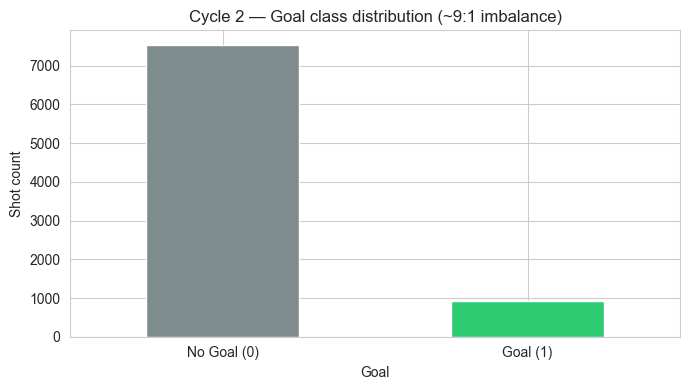

In [8]:
shots['Goal'] = shots['tags'].apply(lambda tags: int(any(t['id']==101 for t in tags)))
# Tag 101 = Goal in Wyscout tag vocabulary — binary: 1 if this shot was a goal, 0 otherwise

print('Goal target distribution:')
print(shots['Goal'].value_counts())              # counts of goals vs non-goals
print(f'Goal rate: {shots["Goal"].mean()*100:.2f}%')  # ~10.8% — strong class imbalance

fig, ax = plt.subplots(figsize=(7,4))
counts = shots['Goal'].value_counts().sort_index()
counts.plot(kind='bar', color=['#7f8c8d','#2ecc71'], ax=ax)  # grey=no goal, green=goal
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(['No Goal (0)','Goal (1)'][:len(counts)], rotation=0)
ax.set_title('Cycle 2 — Goal class distribution (~9:1 imbalance)')
ax.set_ylabel('Shot count')
plt.tight_layout(); plt.show()


- **10.82%** of shots become goals — **8.25:1 class imbalance** 
- A model that always predicts "No Goal" achieves 89.18% accuracy. This is why AUC, not accuracy, will be used as the primary metric.

### Pre-Shot vs Post-Shot (Leakage Audit)

This step identifies and removes post-shot Wyscout tags (1201–1218) to prevent data leakage, keeping only pre-shot tags (401–403) as valid features for the xG model.

In [9]:
from collections import Counter  # count tag occurrences across all shots

all_tags = Counter()               # accumulate counts for each unique tag ID
for tags in shots['tags']:         # iterate over each shot's tag list
    for t in tags:
        all_tags[t['id']] += 1    # increment count for this tag ID

# Manual tag meaning lookup — distinguishes pre-shot knowable from post-shot leakage
tag_meaning = {
    101: 'Goal — TARGET, never a feature',
    102: 'Own goal',
    401: 'Left foot — PRE-SHOT (knowable)',
    402: 'Right foot — PRE-SHOT (knowable)',
    403: 'Header/body — PRE-SHOT (knowable)',
    1801:'Accurate (post-event flag)',
    1802:'Inaccurate',
    1201:'Goal-low-centre — POST-SHOT, LEAKAGE',
    1202:'Goal-low-right — POST-SHOT, LEAKAGE',
    1203:'Goal-low-left — POST-SHOT, LEAKAGE',
    1204:'Goal-mid-centre — POST-SHOT, LEAKAGE',
    1205:'Goal-mid-right — POST-SHOT, LEAKAGE',
    1206:'Goal-mid-left — POST-SHOT, LEAKAGE',
    1207:'Goal-high-centre — POST-SHOT, LEAKAGE',
    1208:'Goal-high-right — POST-SHOT, LEAKAGE',
    1209:'Goal-high-left — POST-SHOT, LEAKAGE',
    1210:'Out-low-centre — POST-SHOT, LEAKAGE',
    1211:'Out-low-right — POST-SHOT, LEAKAGE',
    1212:'Out-low-left — POST-SHOT, LEAKAGE',
    1213:'Out-mid-right — POST-SHOT, LEAKAGE',
    1214:'Out-mid-left — POST-SHOT, LEAKAGE',
    1215:'Out-high-centre — POST-SHOT, LEAKAGE',
    1216:'Out-high-right — POST-SHOT, LEAKAGE',
    1217:'Out-high-left — POST-SHOT, LEAKAGE',
    1218:'Out-mid-centre — POST-SHOT, LEAKAGE',
}

print(f'{"Tag":>6}  {"Count":>7}  Meaning')
print('-' * 70)
for tag_id, count in all_tags.most_common():  # print tags in descending frequency order
    meaning = tag_meaning.get(tag_id, '(other / not used)')
    print(f'{tag_id:>6}  {count:>7}  {meaning}')


   Tag    Count  Meaning
----------------------------------------------------------------------
   201     5917  (other / not used)
  1802     5465  Inaccurate
   402     4349  Right foot — PRE-SHOT (knowable)
  1801     2986  Accurate (post-event flag)
   401     2785  Left foot — PRE-SHOT (knowable)
  2101     2271  (other / not used)
   403     1317  Header/body — PRE-SHOT (knowable)
   101      914  Goal — TARGET, never a feature
  1201      793  Goal-low-centre — POST-SHOT, LEAKAGE
  1210      606  Out-low-centre — POST-SHOT, LEAKAGE
  1212      605  Out-low-left — POST-SHOT, LEAKAGE
  1216      585  Out-high-right — POST-SHOT, LEAKAGE
  1215      507  Out-high-centre — POST-SHOT, LEAKAGE
  1203      506  Goal-low-left — POST-SHOT, LEAKAGE
  1205      458  Goal-mid-right — POST-SHOT, LEAKAGE
  1901      425  (other / not used)
  1214      410  Out-mid-left — POST-SHOT, LEAKAGE
  1202      405  Goal-low-right — POST-SHOT, LEAKAGE
  1204      254  Goal-mid-centre — POST-SHOT, LEAKAG

### Spatial Distribution of Shots

This step extracts shot coordinates and visualises their distribution, confirming that shots closer to goal and central areas have a much higher probability of scoring.

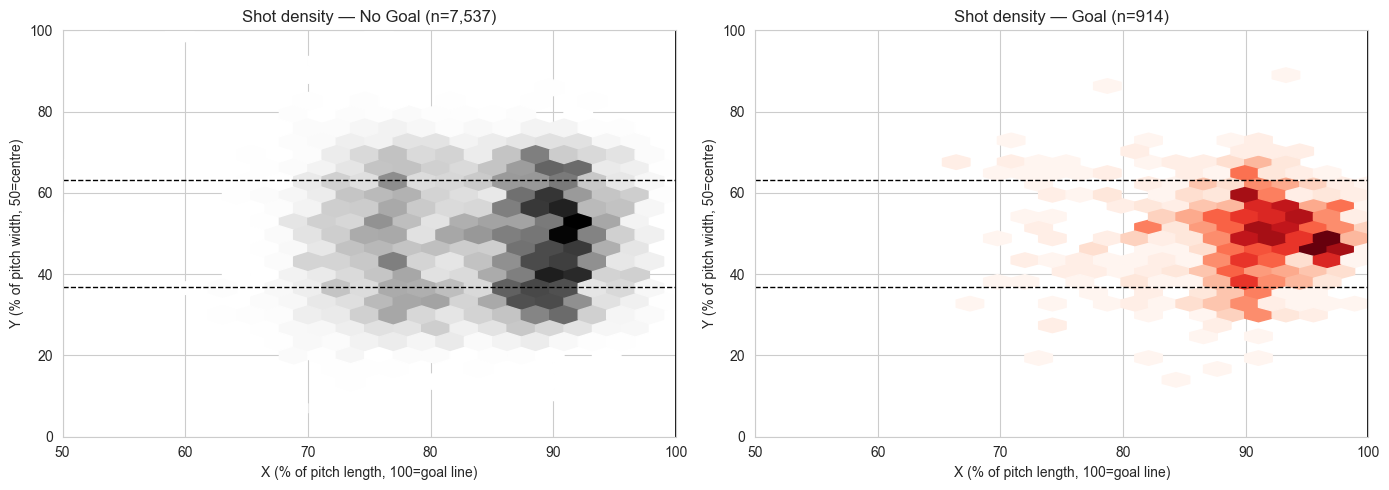

In [10]:
# Shot location is in positions[0]: X (0-100, 100=goal line), Y (0-100, 50=centre width)
shots['X'] = shots['positions'].apply(lambda p: p[0]['x'])  # X-coordinate (pitch length axis)
shots['Y'] = shots['positions'].apply(lambda p: p[0]['y'])  # Y-coordinate (pitch width axis)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # side-by-side: non-goals vs goals
for ax, goal_class, label in zip(axes, [0, 1], ['No Goal','Goal']):
    sub = shots[shots['Goal'] == goal_class]       # subset by outcome
    ax.hexbin(sub['X'], sub['Y'], gridsize=25,     # hexbin: hex cells show density
              cmap='Reds' if goal_class else 'Greys', mincnt=1)
    ax.set_xlim(50, 100)   # show only attacking half of pitch
    ax.set_ylim(0, 100)
    ax.axvline(100, color='black', lw=2)             # goal line
    ax.axhline(36.8, color='black', lw=1, linestyle='--')  # penalty area left post
    ax.axhline(63.2, color='black', lw=1, linestyle='--')  # penalty area right post
    ax.set_xlabel('X (% of pitch length, 100=goal line)')
    ax.set_ylabel('Y (% of pitch width, 50=centre)')
    ax.set_title(f'Shot density — {label} (n={len(sub):,})')
plt.tight_layout(); plt.show()


Goals are concentrated close to the goal and centrally, while non-goals occur more from distance and wide angles, confirming that distance and angle are the strongest predictors for xG.

### Distance and Angle to Goal

This step engineers the key xG features—Distance and Angle—to quantify how far and how open the goal is for each shot, showing that closer and wider-angle shots are far more likely to result in goals.

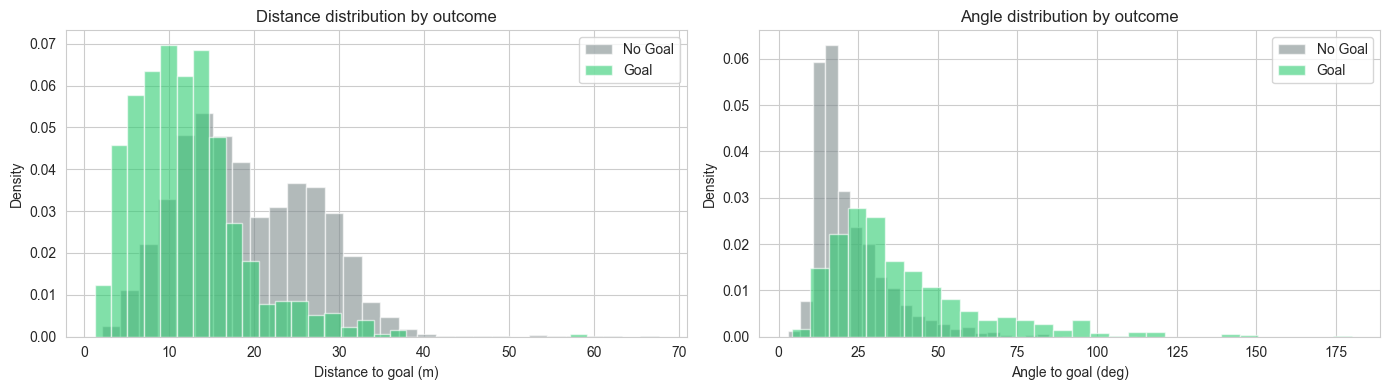

Distance — Goals: 12.1 m
Distance — No Goal: 19.0 m
Angle    — Goals: 38.6 deg
Angle    — No Goal: 22.6 deg


In [11]:
PITCH_L, PITCH_W = 105.0, 68.0          # standard pitch dimensions in metres
POST_L, POST_R = 30.34, 37.66           # goal post positions along pitch width (metres)
GOAL_Y = (POST_L + POST_R) / 2          # goal centre Y-position in metres (34.0)

x_m = shots['X'] / 100.0 * PITCH_L     # convert % X to metres
y_m = shots['Y'] / 100.0 * PITCH_W     # convert % Y to metres
shots['Distance'] = np.sqrt((x_m - PITCH_L)**2 + (y_m - GOAL_Y)**2)  # Euclidean distance to goal centre
dx = PITCH_L - x_m                      # horizontal distance to goal line
shots['Angle'] = np.abs(np.degrees(
    np.arctan2(POST_R-y_m, dx) - np.arctan2(POST_L-y_m, dx)  # angle subtended by goal posts
))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for cls, color, label in [(0, '#7f8c8d','No Goal'), (1, '#2ecc71','Goal')]:
    sub = shots[shots['Goal']==cls]
    axes[0].hist(sub['Distance'], bins=30, alpha=0.6, color=color, label=label, density=True)
    axes[1].hist(sub['Angle'],    bins=30, alpha=0.6, color=color, label=label, density=True)
axes[0].set_xlabel('Distance to goal (m)'); axes[0].set_ylabel('Density'); axes[0].legend()
axes[0].set_title('Distance distribution by outcome')
axes[1].set_xlabel('Angle to goal (deg)'); axes[1].set_ylabel('Density'); axes[1].legend()
axes[1].set_title('Angle distribution by outcome')
plt.tight_layout(); plt.show()

print('Distance — Goals:', shots[shots.Goal==1]['Distance'].mean().round(1), 'm')     # goals: ~12m
print('Distance — No Goal:', shots[shots.Goal==0]['Distance'].mean().round(1), 'm')   # non-goals: ~19m
print('Angle    — Goals:', shots[shots.Goal==1]['Angle'].mean().round(1), 'deg')      # goals: wider angle
print('Angle    — No Goal:', shots[shots.Goal==0]['Angle'].mean().round(1), 'deg')


## Shots by body part Outcome
This step encodes shot body type (left foot, right foot, header) from pre-shot tags and shows that different shot types have different scoring probabilities, adding useful predictive signal beyond location.


In [12]:
shots['Left_Foot']  = shots['tags'].apply(lambda t: int(any(x['id']==401 for x in t)))  # tag 401 = left foot
shots['Right_Foot'] = shots['tags'].apply(lambda t: int(any(x['id']==402 for x in t)))  # tag 402 = right foot
shots['Header']     = shots['tags'].apply(lambda t: int(any(x['id']==403 for x in t)))  # tag 403 = header/body

for col in ['Left_Foot','Right_Foot','Header']:
    rate = shots.groupby(col)['Goal'].mean() * 100          # goal rate when this body part used (1) vs not (0)
    n    = shots[col].sum()                                  # total shots of this type
    print(f'{col} (n={n}): goal rate when 1 = {rate.get(1,0):.2f}% | when 0 = {rate.get(0,0):.2f}%')


Left_Foot (n=2785): goal rate when 1 = 10.52% | when 0 = 10.96%
Right_Foot (n=4349): goal rate when 1 = 10.19% | when 0 = 11.48%
Header (n=1317): goal rate when 1 = 13.52% | when 0 = 10.32%


- Headers actually convert at a HIGHER rate than foot shots: (13.52%) when header=1 vs (10.32%) when header=0
- Reason: headers in this dataset come almost entirely from inside the box on crosses and corners — distance for headers is 10.3 m vs 19.3-20.1 m for foot shots, and mean angle is 38.8° vs ~21.5°. They are selected for being close-range, high-angle opportunities
- Right vs left foot rates are similar - (10.19% vs 10.52%) — handedness has no detectable effect on conversion. Right-foot shots are more common (51.5%) since most players are right-footed
- Body part is therefore a useful but secondary feature — its main value is correlating with shot type rather than introducing independent information

### Match-Half Effect

This step filters to normal match time and adds a first-half indicator, showing whether shot conversion differs between halves while avoiding noisy extra-time data.


In [13]:
shots = shots[shots['matchPeriod'].isin(['1H','2H'])].copy()  # drop extra-time shots (OT/ET)
shots['First_Half'] = (shots['matchPeriod']=='1H').astype(int)  # binary: 1=first half, 0=second half

for half in [1, 0]:
    sub = shots[shots['First_Half']==half]
    print(f'{"First Half" if half else "Second Half"}: '
          f'shots={len(sub):,}, goal rate={sub["Goal"].mean()*100:.2f}%')  # compare conversion rates


First Half: shots=3,954, goal rate=9.81%
Second Half: shots=4,497, goal rate=11.70%


- Goal rate is slightly **higher in the second half** (fatigue, late-game tactical changes, push for result)
- Effect size is small — match-half is the weakest of the available pre-shot features

### Correlation HeatMap

Computing and visualises feature correlations with the goal outcome, confirming that Distance and Angle have the strongest predictive relationship and should be prioritised in the xG model.

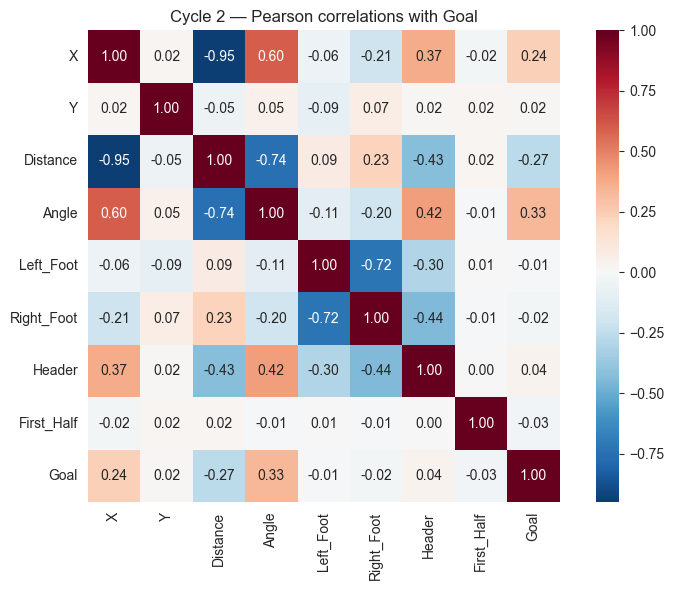

Correlations with Goal:
  Angle          +0.331
  Distance       -0.270
  X              +0.238
  Header         +0.037
  First_Half     -0.030
  Right_Foot     -0.021
  Y              +0.015
  Left_Foot      -0.007


In [14]:
# Build a temporary feature frame with all computed features + target for correlation analysis
feat_df = shots[['X','Y','Distance','Angle','Left_Foot','Right_Foot','Header','First_Half','Goal']].copy()
corr = feat_df.corr()                                        # Pearson correlation matrix
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',     # RdBu_r: blue=negative, red=positive
            center=0, square=True, ax=ax)                    # center=0 so neutral correlation = white
ax.set_title('Cycle 2 — Pearson correlations with Goal')
plt.tight_layout(); plt.show()

print('Correlations with Goal:')
for col, c in corr['Goal'].drop('Goal').sort_values(key=abs, ascending=False).items():
    print(f'  {col:<14} {c:+.3f}')  # sorted by absolute correlation — most predictive first


- **Angle (+0.331) is the single strongest predictor** of goal — wider angle = more of the goal mouth visible = higher chance of scoring

- **Distance (-0.270) is the strongest negative predictor** — closer is better. Angle and Distance are the two dominant features

- **X (+0.238) is largely redundant with Distance** — they encode the same information (position along the pitch length)
- Body-part features have **near-zero linear correlation** with the target individually (Header +0.04, others < 0.04), but contribute through interactions with location
- These linear correlations underestimate true predictive power; non-linear models (XGBoost) will extract substantially more by capturing interactions like `Distance × Angle` and `Header × Distance`

## Outlier (IQR method)

Find unusual values (outliers) in each numeric feature using the IQR method.

In [15]:
def iqr_outliers(s):           # IQR outlier detection function
    q1, q3 = s.quantile([0.25, 0.75])  # lower and upper quartiles
    iqr = q3 - q1                       # interquartile range
    return ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum(), q1 - 1.5*iqr, q3 + 1.5*iqr

for col in ['X','Y','Distance','Angle']:  # audit all continuous features
    n, lo, hi = iqr_outliers(shots[col])
    print(f'{col:<10}: outliers={n:>4} ({n/len(shots)*100:.1f}%), IQR fence [{lo:.1f}, {hi:.1f}]')

# Sanity check: any shot from own half? (X<50 = defending half — physically unusual)
own_half = (shots['X'] < 50).sum()
print(f'\nShots from own half (X<50): {own_half} ({own_half/len(shots)*100:.2f}%)')


X         : outliers=  18 (0.2%), IQR fence [61.0, 109.0]
Y         : outliers=   5 (0.1%), IQR fence [6.5, 90.5]
Distance  : outliers=  20 (0.2%), IQR fence [-6.5, 43.3]
Angle     : outliers= 474 (5.6%), IQR fence [-7.5, 51.6]

Shots from own half (X<50): 8 (0.09%)


# EDIT 
- **Distance outliers (20 rows, 0.2%) are long-range shots beyond the IQR fence (~43 m)** — legitimate but rare. Do not remove
- **Angle outliers (474 rows, 5.6%) are NOT "impossible-angle" shots** — they are exactly the opposite. These are **close-range shots from inside the 6-yard box** (mean distance 5.4 m, mean X=95.3) where the angle to goal is naturally wide (>51°). They convert at a **41.6% goal rate** vs 9.0% for the rest of the dataset — the highest-quality chances in football. **Definitely do not remove**
- A small number of "shots" originate from the player's own half (8 rows, 0.09%) — these are typically goal-kick clearances mis-logged as shots. Volume is too low to affect the model

## Player Rank

Player_Rank is a normalized skill metric that shows a strong monotonic increase in goal probability, making it the most important non-spatial feature in the xG model.

In [18]:
# playerank score is in the processed file (merged during preprocessing) — check it here for context
proc = pd.read_csv(str(Paths.WYSCOUT_PROCESSED))  # load the already-processed output
print(f'Processed file shape: {proc.shape}')
print(f'Processed columns:    {proc.columns.tolist()}')
if 'Player_Rank' in proc.columns:           # only run if the column exists
    print()
    print('Player_Rank distribution:')
    print(proc['Player_Rank'].describe())   # range, mean, std of player skill proxy
    print()
    print('Goal rate by Player_Rank quartile:')
    proc['rank_quartile'] = pd.qcut(proc['Player_Rank'], 4, labels=['Q1','Q2','Q3','Q4'])
    print(proc.groupby('rank_quartile', observed=True)['Goal'].mean().round(3))  # does higher rank = more goals?


Processed file shape: (8451, 10)
Processed columns:    ['X', 'Y', 'Distance', 'Angle', 'Left_Foot', 'Right_Foot', 'Header', 'First_Half', 'Player_Rank', 'Goal']

Player_Rank distribution:
count    8451.000000
mean        0.016194
std         0.024039
min        -0.074300
25%         0.001000
50%         0.011900
75%         0.025900
max         0.158500
Name: Player_Rank, dtype: float64

Goal rate by Player_Rank quartile:
rank_quartile
Q1    0.017
Q2    0.080
Q3    0.148
Q4    0.190
Name: Goal, dtype: float64


Player_Rank shows a strong monotonic relationship with goal probability (1.7% → 19.0%), confirming it as a key non-spatial feature capturing player finishing ability.

## EDA Summary 

- The analysis identified data leakage in post-shot Wyscout tags (1201–1218). After removing leakage, the realistic model performance is around AUC ≈ 0.80.

- The most important predictive features are Distance and Angle, which capture shot difficulty, while Player_Rank provides the strongest non-spatial signal, showing an 11× increase in goal probability from lowest to highest quartile. Body part (e.g. headers) and match half contribute smaller but meaningful effects, with headers appearing more effective due to close-range situations.

- The dataset shows class imbalance (≈8:1), making AUC-ROC the appropriate evaluation metric, and maintains spatial symmetry, indicating no bias in pitch orientation.

- Overall, the findings confirm that an effective xG model should rely on pre-shot spatial features, player quality, and clean data without leakage, while retaining rare but meaningful events such as close-range wide-angle shots.
